In [1]:
import numpy as np

from src import adaptive_coupling_study_funcs as study
from src.lib.model.ocp_graphite import Ueq as U0_ocp
from src.lib.reader import  reader as params
from src.lib.model import setup_LIB as setup 

Input basic simulation and physical parameters from input file and a solution of the algebraic system corresponding to initial condition of differential system as initial guess is obtained.

In [2]:
inputFile = 'src/input/'           
phy_options, sim_options = params.readInputs(inputFile)

L_e = phy_options["Electrolyte"]["L_e"]["value"] # m
L_am = phy_options["Electrode"]["L_am"]["value"] # m
L_cc = phy_options["CurrentCollector"]["L_cc"]["value"] # m

D_e_c = phy_options['Electrolyte']['D_e_c']['value'] # m^2/s

L_c = L_e + L_am + L_cc # m
tc = (L_c ** 2) / D_e_c # s --> Timescale for dimensionless times

Setup of the study

In [3]:
cvType = 'sinewave' # Oscillating sinewave voltage operating condition

order_vec= np.array(range(1, 4 + 1)) # Vector of orders of coupling studied

tini_dim = 0.0 # Simulation start time in s
t_transient_dim = 1e-10 # The transient time in s for which an initial monolithic simulation is run with first-order backward Euler (BE) method to obtain consistent initial algebraic variables
nt_transient = 2 # steps taken by transient BE simulation
tend_dim = 501.0 # Time in s at which CV mode simulation ends

# Dimensionless times
tini = tini_dim/tc # Dimensionless time for CC mode start
t_transient = t_transient_dim/tc # Dimensionless time for CC mode end or CV mode simulation start
tend = tend_dim/tc # Dimensionless time for CV mode simulation end 

t_md_start = t_transient # Dimensionless time for the start of multi-domain coupled simulations
t_md_end = tend # Dimensionless time for the start of multi-domain coupled simulations

# Tolerance for md simulation with adaptive coupling
dt_rtol = 5e-6


Setting up CV mode LIB simulations

In [4]:
socI = 0.5 # start from 50% state of charge
c_s_max = phy_options["Electrode"]["c_s_max"]["value"] # mol/m^3
Umean =  U0_ocp(socI) # starting voltage set at equal to electrode open circuit potential at initial SoC in Volts 

sim_options["ChargeRate"]["type"]["value"] = "CV"   
sim_options["ChargeRate"]["xi"]["value"] = 1.0
sim_options["ChargeRate"]["c_s_i"]["value"] = socI * c_s_max
sim_options["ChargeRate"]["phi_s_L"]["value"] = lambda t : Umean
    
# U0 = Umean
dev = 0.05 
tspan = abs(t_md_end - t_md_start)
osc = 3 # Keep it odd 
tperiod = 2*np.pi
omega = tperiod * osc

signalU = lambda t: Umean*(1. - dev*np.sin(omega * t)) # sinewave voltage signal
Ucell_t  = lambda t: signalU(t/tspan) # sinewave voltage 

options_electrolyte, options_cathode = setup.getSetup(phy_options, sim_options, invertBV=False)
Ui = np.r_[options_electrolyte['y0'], options_cathode['y0']] # Initial condition solution

options_cathode['parameters']['ChargeType'] = "CV"
options_cathode['parameters']['phi_s_L'] = Ucell_t

No. of Newton iterations =  2
[0:c_e_0_plus, 1:phi_e_0_plus, 2:c_e_ne_minus, 3:phi_e_ne_minus, 4:c_s_0_plus,  5:phi_s_0_plus, 6:ise]
[0.99999378 0.09998864 0.99999977 0.09999959 0.50004852 4.03259077]


Initial monolithic simulation until transient time, t=1e-10s, using first-order implicit BE method. This smoothens the initial guess for multi-domain simulation (here, we do not use a precursor CC mode simulation) such that it can start with larger coupling intervals.  

In [5]:
options_cathode['sim_type']="monolithic"
options_electrolyte['sim_type']="monolithic"

out_transient = study.initial_transient_sim(
                        tini=tini,
                        tend=t_transient,
                        y0=Ui,
                        nt=nt_transient,
                        options_electrolyte=options_electrolyte,
                        options_cathode=options_cathode
)

---------------------------------- 
Time integration begins
.
.
Simulation completed
time = 0.00 s 	 voltage = 0.10360010 volts
--------------------------------------------------------------------------------


Quasi-exact reference monolithic solution

In [6]:
options_cathode['sim_type']="monolithic"
options_electrolyte['sim_type']="monolithic"

ref_sol_monolithic = study.get_ref_sol(
                      y0=out_transient.y[:,-1],
                      tstart=t_md_start,
                      tend=t_md_end,
                      rtol=1e-12,
                      options_electrolyte=options_electrolyte,
                      options_cathode=options_cathode
)

Reference solution CV computed
  --> "The solver successfully reached the end of the integration interval."


Voltage evolution during oscillating voltage mode of operation

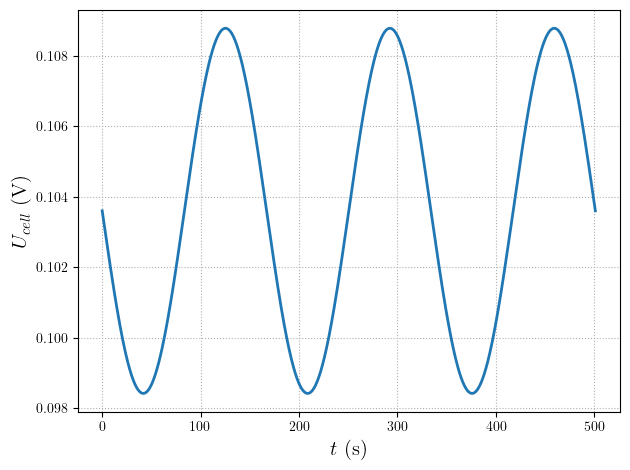

In [7]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}' 
rcParams['text.usetex'] = True

time_vec = ref_sol_monolithic.t[:] * tc
Ucell_vec = ref_sol_monolithic.y[-1, :] * options_electrolyte['parameters']['phi_c']

plt.figure()
plt.plot(time_vec, Ucell_vec,
         color='C0', lw=2, ls='-')

plt.xlabel(r"$t\ \mathrm{(s)}$", fontsize=15)
plt.ylabel(r"$U_{cell}\ \mathrm{(V)}$", fontsize=15)
plt.grid(ls=':')
plt.tight_layout()

Multi-domain LIB simulation with adaptive coupling 

In [8]:
options_cathode['sim_type']="md_coupling_vars"
options_electrolyte['sim_type']="md_coupling_vars"

nparallel=4
    
# Only implicit coupling studied for demonstration
sols_md_implicit = study.adaptive_md_study_loop(
                                        order_vec,
                                        t_md_start,
                                        t_md_end,
                                        y0_global=out_transient.y[:,-1],
                                        dt_rtol=dt_rtol,
                                        bExplicitCoupling=False,
                                        options_electrolyte=options_electrolyte,
                                        options_cathode=options_cathode,
                                        bMDSim_v1=False,
                                        nparallel=nparallel
)

sols_md_implicit_v1 = study.adaptive_md_study_loop(
                                        order_vec,
                                        t_md_start,
                                        t_md_end,
                                        y0_global=out_transient.y[:,-1],
                                        dt_rtol=dt_rtol,
                                        bExplicitCoupling=False,
                                        options_electrolyte=options_electrolyte,
                                        options_cathode=options_cathode,
                                        bMDSim_v1=True,
                                        nparallel=nparallel
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
Tolerances for adaptive simulation
-------------------
     rtol dt = 5e-06,
    WR_rtol = 1.0000000000000002e-06,
    WR_atol = 1.0000000000000002e-06,
    rtol subsys = 2.5000000000000004e-07

Tolerances for adaptive simulation
-------------------
     rtol dt = 5e-06,
    WR_rtol = 1.0000000000000002e-06,
    WR_atol = 1.0000000000000002e-06,
    rtol subsys = 2.5000000000000004e-07

Tolerances for adaptive simulation
-------------------
     rtol dt = 5e-06,
    WR_rtol = 1.0000000000000002e-06,
    WR_atol = 1.0000000000000002e-06,
    rtol subsys = 2.5000000000000004e-07

Tolerances for adaptive simulation
-------------------
     rtol dt = 5e-06,
    WR_rtol = 1.0000000000000002e-06,
    WR_atol = 1.0000000000000002e-06,
    rtol subsys = 2.5000000000000004e-07

[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:    5.1s
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:    5.5s remaining:    5.5s
[Par

Plot parameters

In [9]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}' 
rcParams['text.usetex'] = True
plt.style.use = 'science'

clrmap = plt.get_cmap("tab10") 
clr =  [clrmap(i) for i in range(10)]
malpha = 0.75
mfc = [(i[0], i[1], i[2], malpha) for i in clr]
mrk = ['o', 'v', 's', 'd']
fzA=15

$\Delta t_c$ vs. $t$ plots

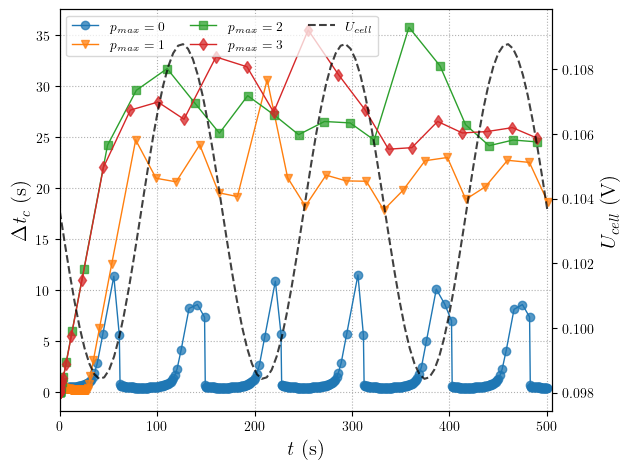

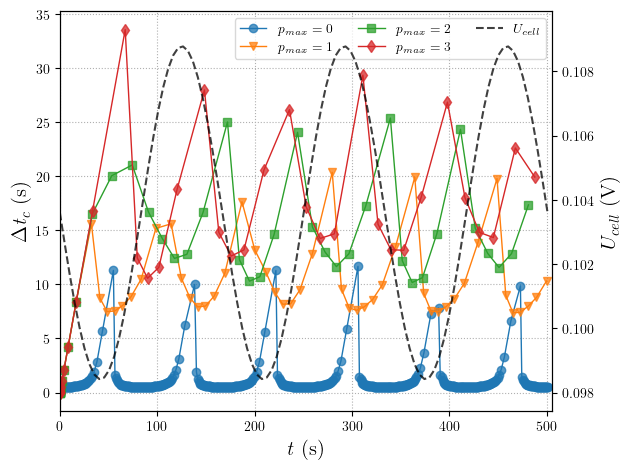

In [10]:
t_vecs=[]
dt_vecs=[]
for i in range(len(order_vec)):
    if sols_md_implicit[i] is None:
        t_vecs.append(np.nan)
        dt_vecs.append(np.nan)
    else:
        t_vecs.append(sols_md_implicit[i].t[1:-1]*tc)
        dt_vecs.append(np.diff(sols_md_implicit[i].t)[:-1]*tc)

kdt = 5 # skip the very small initial coupling intervals
fig1 = plt.figure()    
ax_l = fig1.add_subplot(1,1,1)  
for i, current_order in enumerate(order_vec):
    dt_vec = dt_vecs[i]
    t_vec = t_vecs[i]
    if np.isnan(t_vec).any():
        lbl=None
    else:
        lbl=f"$p_{{max}} = \mathrm{ {current_order-1} }$"
        ax_l.plot(t_vec[kdt:], dt_vec[kdt:], label=lbl,
                   lw=1, linestyle='-', color=clr[i],
                   marker=mrk[i], markersize=6, markeredgewidth=1, mfc=mfc[i])
        
ax_r = ax_l.twinx()
tt_vec = np.linspace(t_md_start, t_md_end, num=100)
Ucell_applied = Ucell_t(tt_vec)

ax_r.plot(tt_vec*tc, Ucell_applied,
              ls='--', c='k', alpha=.75, lw=1.5)

ax_l.plot(np.nan, np.nan,
          'k--', alpha=.75, lw=1.5,
          label=r"$U_{cell}$")

ax_l.grid(ls=':')
ax_l.set_xlabel(r"$\mathrm{\mathit{t}\ (s)} $", fontsize=fzA)
ax_l.set_ylabel(r"$\mathrm{\Delta \mathit{t_{c}}\ (s)}$", fontsize=fzA)
ax_r.set_ylabel(r"$U_{cell}\ \mathrm{(V)}$", fontsize=fzA)
ax_l.legend(loc=0, framealpha=0.75, numpoints=1, ncol=3, fontsize=fzA-5.5)

# ax_l.set_ylim(0,35)
ax_r.set_ylim(.99*min(Ucell_applied),1.01*max(Ucell_applied))

plt.xlim(0.99*t_transient_dim, 1.01*tend_dim)
plt.tight_layout()



t_vecs_v1=[]
dt_vecs_v1=[]
for i in range(len(order_vec)):
    if sols_md_implicit_v1[i] is None:
        t_vecs_v1.append(np.nan)
        dt_vecs_v1.append(np.nan)
    else:
        t_vecs_v1.append(sols_md_implicit_v1[i].t[1:-1]*tc)
        dt_vecs_v1.append(np.diff(sols_md_implicit_v1[i].t)[:-1]*tc)

kdt = 5 # skip the very small initial coupling intervals
fig1_v1 = plt.figure()    
ax_l = fig1_v1.add_subplot(1,1,1)  
for i, current_order in enumerate(order_vec):
    dt_vec = dt_vecs_v1[i]
    t_vec = t_vecs_v1[i]
    if np.isnan(t_vec).any():
        lbl=None
    else:
        lbl=f"$p_{{max}} = \mathrm{ {current_order-1} }$"
        ax_l.plot(t_vec[kdt:], dt_vec[kdt:], label=lbl,
                   lw=1, linestyle='-', color=clr[i],
                   marker=mrk[i], markersize=6, markeredgewidth=1, mfc=mfc[i])
        
ax_r = ax_l.twinx()
tt_vec = np.linspace(t_md_start, t_md_end, num=100)
Ucell_applied = Ucell_t(tt_vec)

ax_r.plot(tt_vec*tc, Ucell_applied,
              ls='--', c='k', alpha=.75, lw=1.5)

ax_l.plot(np.nan, np.nan,
          'k--', alpha=.75, lw=1.5,
          label=r"$U_{cell}$")

ax_l.grid(ls=':')
ax_l.set_xlabel(r"$\mathrm{\mathit{t}\ (s)} $", fontsize=fzA)
ax_l.set_ylabel(r"$\mathrm{\Delta \mathit{t_{c}}\ (s)}$", fontsize=fzA)
ax_r.set_ylabel(r"$U_{cell}\ \mathrm{(V)}$", fontsize=fzA)
ax_l.legend(loc=0, framealpha=0.75, numpoints=1, ncol=3, fontsize=fzA-5.5)

# ax_l.set_ylim(0,35)
ax_r.set_ylim(.99*min(Ucell_applied),1.01*max(Ucell_applied))

plt.xlim(0.99*t_transient_dim, 1.01*tend_dim)
plt.tight_layout()

$i_{BV}^{(C)}$ vs. $t$ plots

In [11]:
# skp = [] # skipping data points to improve visibility
# for i in range(order_vec.size):
#     tsz = sols_md_implicit[i].t.size if sols_md_implicit[i] is not None else None
#     if tsz is not None and tsz > 100:
#         skp.append(tsz//100)
#     else:
#         skp.append(None)

# from src.lib.model import bv_current as bv
# ne = options_electrolyte['nCells']
# cec = options_electrolyte['parameters']['c_e_c']
# phic = options_electrolyte['parameters']['phi_c']
# csc = options_cathode['activematerial']['parameters']['c_s_c']

# tt_vec = np.linspace(t_md_start, t_md_end, num=100)
# ref_sol_y = ref_sol_monolithic.sol(tt_vec)

# ise_ref = bv.ise_C(ref_sol_y[2*ne+2,:]*cec,
#                   ref_sol_y[2*ne+3,:]*phic,
#                   ref_sol_y[2*ne+4,:]*csc,
#                   ref_sol_y[2*ne+5,:]*phic,
#                   options_electrolyte,
#                   options_cathode)

# fig2 = plt.figure()    
# ax = fig2.add_subplot(1,1,1)  
# iseT = []
# simT = []
# for i, current_order in enumerate(order_vec):
#     if sols_md_implicit[i] is not None:
#         ise_t = bv.ise_C(sols_md_implicit[i].z[0][::skp[i]]*cec,
#                           sols_md_implicit[i].z[1][::skp[i]]*phic,
#                           sols_md_implicit[i].z[2][::skp[i]]*csc,
#                           sols_md_implicit[i].z[3][::skp[i]]*phic,
#                           options_electrolyte,
#                           options_cathode)
        
#         ax.plot(sols_md_implicit[i].t[::skp[i]]*tc, ise_t,
#                   lw=1,  linestyle=' ', 
#                   marker=mrk[i], markersize=6, markeredgewidth=1, mfc=mfc[i],
#                   label=f"$p_{{max}} =  \mathrm{ {current_order-1} } $")
#         iseT.append(ise_t)
#         simT.append(sols_md_implicit[i].t[::skp[i]]*tc)
        
# ax.plot(tt_vec*tc, ise_ref,
#           'k--', lw=1.5, alpha=.75, label=r"$\mathrm{ref.\ sol.}$")
    
# ax.set_xlabel(r"$t\ \mathrm{(s)}$", fontsize=fzA)
# ax.set_ylabel(r"$i_{{BV}}^{{(C)}}\ \mathrm{(A/m^2)}$", fontsize=fzA)
# ax.set_xlim(-8, 1.01*tend_dim)

# ax.grid(ls=':')
# ax.legend(loc=0, framealpha=0.75, ncol=1, numpoints=1, fontsize=fzA-5)
# plt.tight_layout()

Save results 

In [12]:
bSavefig = False      
if bSavefig:
    savepath = 'output/'    
    if bExplicit:
        fig1.savefig(savepath+f"fig_{cvType}CV_exp_tfin{int(tend_dim)}_pmax{order_vec[-1]}.pdf", dpi=600)
        fig2.savefig(savepath+f"fig_{cvType}CV_exp_tfin{int(tend_dim)}_pmax{order_vec[-1]}_iBV.pdf", dpi=600)
    else:
        fig1.savefig(savepath+f"fig_{cvType}CV_fp_tfin{int(tend_dim)}_pmax{order_vec[-1]}.pdf", dpi=600)
        fig2.savefig(savepath+f"fig_{cvType}CV_fp_tfin{int(tend_dim)}_pmax{order_vec[-1]}_iBV.pdf", dpi=600)